In [4]:
# submesoscale eddy
from smode_import import *
from parula import parula
from cmocean import cm as cm

In [6]:
path = '/Users/elise/data/SMODE-data/'
#ctd = xr.open_mfdataset(glob(path+'ShipBoardCTD/S_MODE_IOP2_*.nc'))
#ADCP = xr.open_mfdataset(glob(path+'ShipBoardADCP/*.nc')[-1])

#files = sorted(glob(path+'ShipBoardEcoCTD/S_MODE_IOP2_SR2307_EcoCTD_L2*.nc'))[1:]
files = sorted(glob(path+'ShipBoardEcoCTD/S_MODE_IOP2_SR2307_MVP_L2*.nc'))
ds = xr.open_dataset(files[0])
print(xr.open_dataset(files[0]).time[0].values,xr.open_dataset(files[-1]).time[0].values)
ds

2023-04-16T02:59:26.999997952 2023-05-02T03:29:03.999995392


<xarray.Dataset> Size: 19kB
Dimensions:                                     (Time: 101)
Coordinates:
    time                                        (Time) datetime64[ns] 808B ...
    longitude                                   (Time) float64 808B ...
    latitude                                    (Time) float64 808B ...
Dimensions without coordinates: Time
Data variables: (12/20)
    temperature                                 (Time) float64 808B ...
    temperature_QCflag                          (Time) float64 808B ...
    conductivity                                (Time) float64 808B ...
    conductivity_QCflag                         (Time) float64 808B ...
    sea_pressure                                (Time) float64 808B ...
    sea_pressure_QCflag                         (Time) float64 808B ...
    ...                                          ...
    optode_temperature                          (Time) float64 808B ...
    optode_temperature_QCflag                   (Time) float64 808B ...
    turbidity                                   (Time) float64 808B ...
    turbidity_QCflag                            (Time) float64 808B ...
    calibrated_chlorophyll_fluorescence         (Time) float64 808B ...
    calibrated_chlorophyll_fluorescence_QCflag  (Time) float64 808B ...
Attributes: (12/56)
    doi:                           10.5067/SMODE-RVECT
    title:                         SMODE Shipboard MVP Measurements from R/V ...
    summary:                       The dataset includes vertical profiles col...
    keywords_vocabulary:           NASA Global Change Master Directory (GCMD)...
    keywords:                      EARTH SCIENCE > OCEANS > OPTICS > FLUORESC...
    Conventions:                   CF-1.8, ACDD-1.3
    ...                            ...
    time_coverage_start:           2023-04-16T02:59:27Z
    time_coverage_end:             2023-04-16T02:59:27Z
    time_coverage_duration:        P00D00H00M00S
    time_coverage_resolution:      P00DT00H00M00S
    date_created:                  2024-01-03T00:00:00Z
    comment:                       Bio-Optical calibrations performed by Sara...

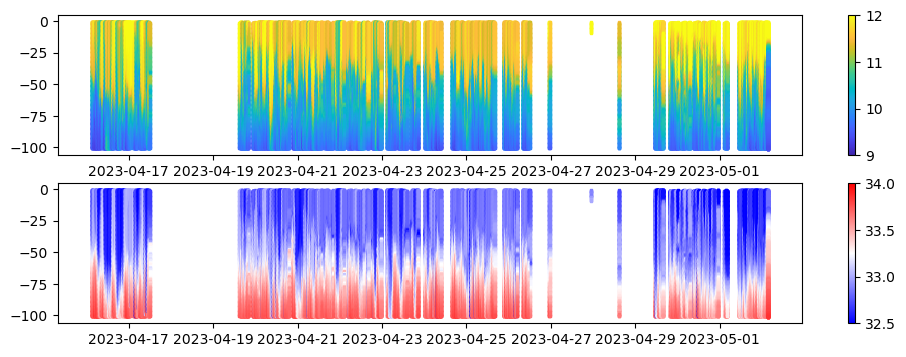

In [38]:
fig,ax = plt.subplots(2,1,figsize=(12,4))
for file in files:
    ds = xr.open_dataset(file)

    pt=ax[0].scatter(ds.time,-ds.sea_pressure,c=ds.temperature, marker='s', s=2, vmin=9, vmax=12, cmap=parula)
    ps=ax[1].scatter(ds.time,-ds.sea_pressure,c=ds.practical_salinity, marker='s', s=2, vmin=32.5, vmax=34, cmap='bwr')

plt.colorbar(pt,ax=ax[0])
plt.colorbar(ps,ax=ax[1])

#for axis in ax:
    #axis.set_ylim(-105,0)
    #axis.set_xlim(pd.Timestamp('2023-04-10'),pd.Timestamp('2023-05-06'))
#    axis.set_xlim(pd.Timestamp('2023-04-19T12'), pd.Timestamp('2023-04-21'))
    #axis.set_xticks(rotation=20)
plt.show();

In [39]:
temp = []
salt = []
o2c  = []
rho  = []
pres = []
time = []
chla = []
turb = []
lat  = []
lon  = []

for file in files[:-2]:
    ds = xr.open_dataset(file)
    time.append(ds.time.mean().values)

    ds_temp = ds.conservative_temperature.values
    ds_salt = ds.absolute_salinity.values
    ds_o2c  = ds.O2_concentration
    ds_chla = ds.calibrated_chlorophyll_fluorescence
    ds_turb = ds.turbidity
    ds_lat = ds.latitude
    ds_lon = ds.longitude
    
    # add flag -- note: i keep all data otherwise surface data disappear
    #ds_temp[ds.conservative_temperature_QCflag.values==0] = np.nan
    #ds_salt[ds.absolute_salinity_QCflag.values==0] = np.nan
    #ds_o2c[ds.O2_concentration_QCflag.values==0] = np.nan
    #ds_chla[ds.calibrated_chlorophyll_fluorescence_QCflag.values==0] = np.nan
    #ds_turb[ds.turbidity_QCflag.values==0] = np.nan
    
    temp.append(ds_temp)
    salt.append(ds_salt)# or absolute_salinity?
    o2c.append(ds_o2c)
    chla.append(ds_chla)
    turb.append(ds_turb)
    lat.append(ds_lat)
    lon.append(ds_lon)

time = np.array(time)
temp = np.array(temp)
salt = np.array(salt)
o2c  = np.array(o2c)
chla = np.array(chla)
turb = np.array(turb)
lat  = np.array(lat)
lon  = np.array(lon)

pres = ds.sea_pressure.values

rho = gsw.density.rho(salt,temp,pres)

# create dataArray
def create_da(data,name):
    da = xr.DataArray(
    data,
    dims=('pressure', 'time'),
    coords={'pressure': pres, 'time': time},
    name=name
    )
    return da

da_lat = create_da(lat.T,'latitude')
da_lon = create_da(lon.T,'longitude')

da_T = create_da(temp.T,'temperature')
da_S = create_da(salt.T,'salinity')
da_R = create_da(rho.T,'potential density')
da_O = create_da(o2c.T,'oxygen concentration')
da_C = create_da(chla.T,'chlorophyll')
da_t = create_da(turb.T,'turbidity')

da = xr.Dataset(
    {    
    'temp': da_T,
    'salt': da_S,
    'rho':  da_R,
    'oxy':  da_O,
    'chla': da_C,
    'turb': da_t,
    'lat': da_lat[0,...],
    'lon': da_lon[0,...]
    },
    coords={
    'pressure': pres,
    'time': time,
    }
)
da.to_netcdf('MVP.nc',mode='w')

In [17]:
# some dataset cleaning
da['salt'] = da['salt'].where(da['salt'] > 32.5)
da['turb'] = da['turb'].where(da['turb'] < 1)
da['oxy'] = da['oxy'].where(da['oxy'] < 400)

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_27099/1083195245.py:21: UserWarning: linewidths is ignored by contourf
  plt.contourf(lons,lats,vor_smoothed/f,np.linspace(-2,2,30),cmap='RdBu_r',linewidths=0.8,extend='both')


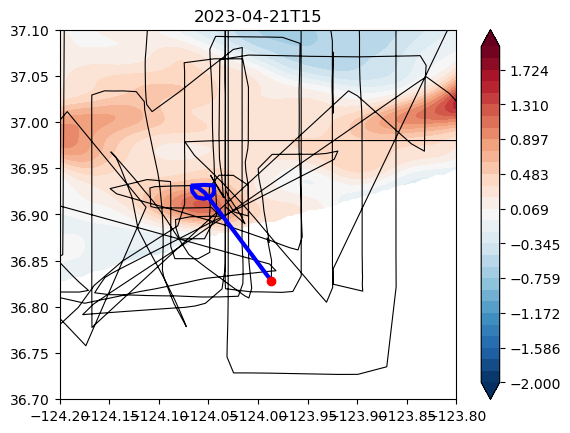

In [148]:
plt.plot(da.lon,da.lat,'k',linewidth=0.8)

def plot_pass(da,t1,t2,color,lw=3):
    da_   = da.sel(time=slice(t1,t2))
    plt.plot(da_.lon, da_.lat, color=color, linewidth=lw)
    plt.plot(da_.lon[0], da_.lat[0], 'or')
    
# triple eddy
#plot_pass(da,'2023-04-20T01', '2023-04-20T02','r')
#plot_pass(da,'2023-04-20T04', '2023-04-20T08','orange')
#plot_pass(da,'2023-04-20T10', '2023-04-20T11','b')
#plt.xlim(-124.2,-123.8); plt.ylim(36.8,37)

# plot dopplerscatt
ds = xr.open_dataset('dopplerscatt_gridded.nc')
#ds_ = ds.sel(time=slice('2023-04-22','2023-04-23')).isel(time=0)
ds_ = ds.sel(time=slice('2023-04-21T10','2023-04-21T18')).isel(time=0)
lons,lats=np.meshgrid(ds_.lon,ds_.lat)
f=coriolis_parameter(37)
vor_smoothed = scipy.ndimage.gaussian_filter(ds_.vorticity,5)
plt.contourf(lons,lats,vor_smoothed/f,np.linspace(-2,2,30),cmap='RdBu_r',linewidths=0.8,extend='both')
plt.colorbar()

# Pass through the cyclonic submesoscale eddy
#plot_pass(da,'2023-04-22T21:20', '2023-04-22T23','b')
plt.xlim(-124.45,-124); plt.ylim(36.7,37.05)

plot_pass(da,'2023-04-21T16', '2023-04-21T17','b')
plt.xlim(-124.2,-123.8); plt.ylim(36.7,37.10)

plt.title(str(ds_.time.values)[0:13])
plt.show();

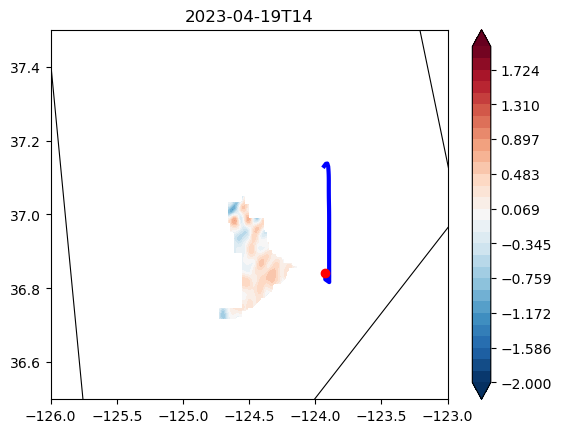

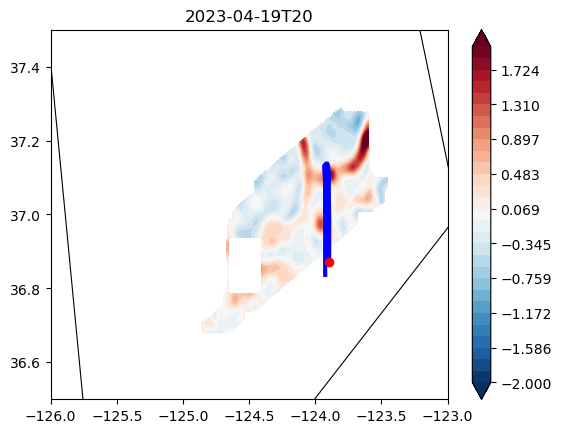

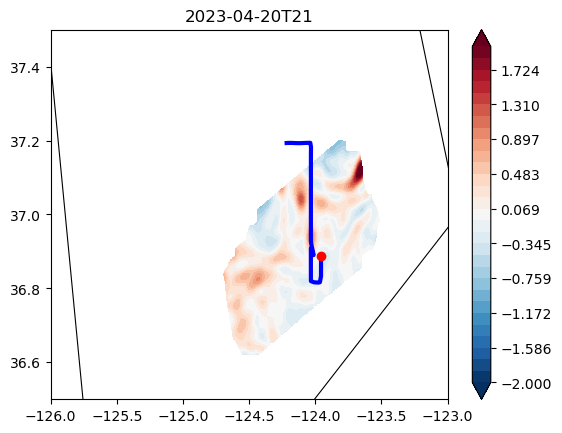

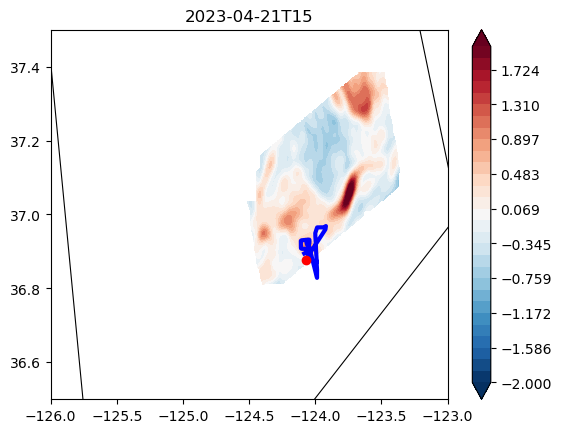

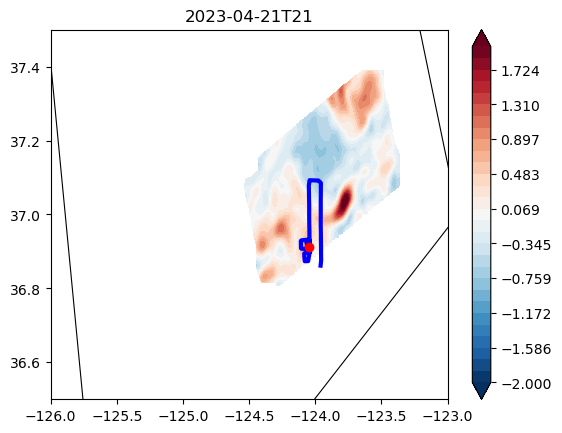

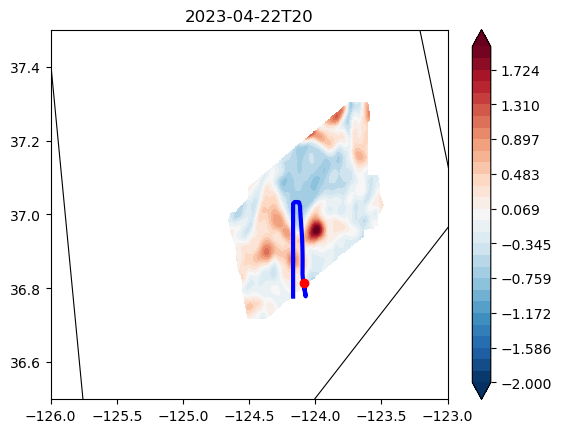

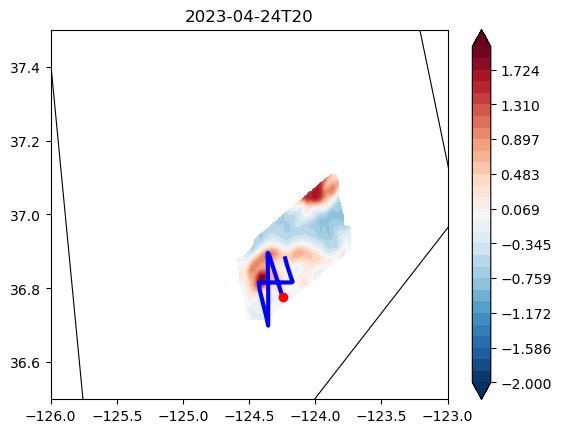

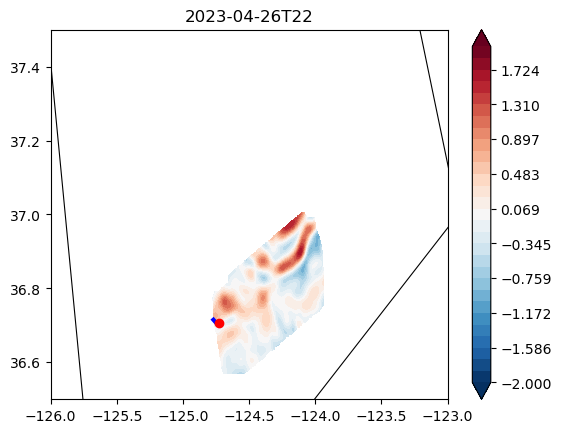

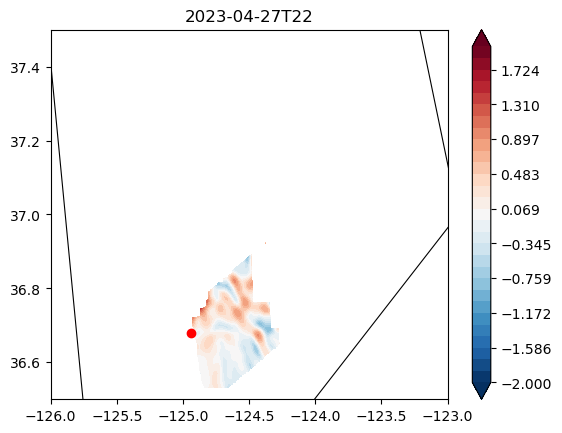

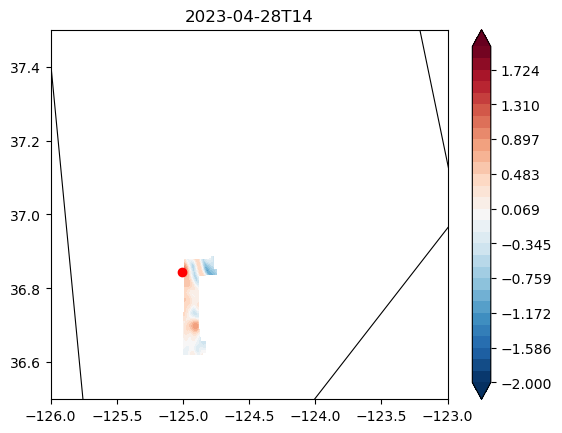

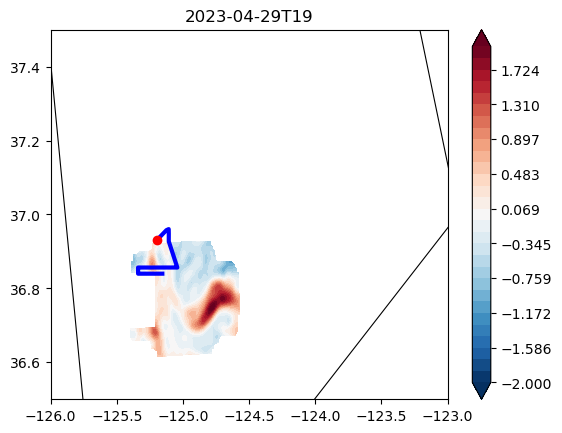

In [158]:
for i in range(ds.sizes['time'])[10::]:
    ds_ = ds.isel(time=i)

    # find nearest time of ship from dopplerscatt snapshot
    nearest_time = da.sel(time=str(ds_.time.values),method='nearest').time
    #print(str(nearest_time.values)[0:13],str(ds.isel(time=i).time.values)[0:13])

    # plot
    plt.figure()
    lons,lats=np.meshgrid(ds_.lon,ds_.lat)
    f=coriolis_parameter(37)
    vor_smoothed = scipy.ndimage.gaussian_filter(ds_.vorticity,5)
    plt.contourf(lons,lats,vor_smoothed/f,np.linspace(-2,2,30),cmap='RdBu_r',extend='both')
    plt.colorbar()

    time_string = str(nearest_time.values)[0:13]
    time_obj = datetime.strptime(time_string, '%Y-%m-%dT%H')

    dt=4
    time_minus = time_obj - timedelta(hours=dt)
    time_plus = time_obj + timedelta(hours=dt)
    
    time_minus_str = time_minus.strftime('%Y-%m-%dT%H')
    time_plus_str = time_plus.strftime('%Y-%m-%dT%H')


    plot_pass(da,time_minus_str,time_plus_str,'b')
    plt.xlim(-126,-123); plt.ylim(36.5,37.5)
    smode_pgon(plt.gca())
    plt.title(time_string)
    plt.show()
    #plt.plot(ds.isel(time=i).time.values,nearest_time.values,'ok')
#plt.xticks(rotation=20);

/opt/anaconda3/lib/python3.12/site-packages/xarray/core/groupby.py:668: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  index_grouper = pd.Grouper(


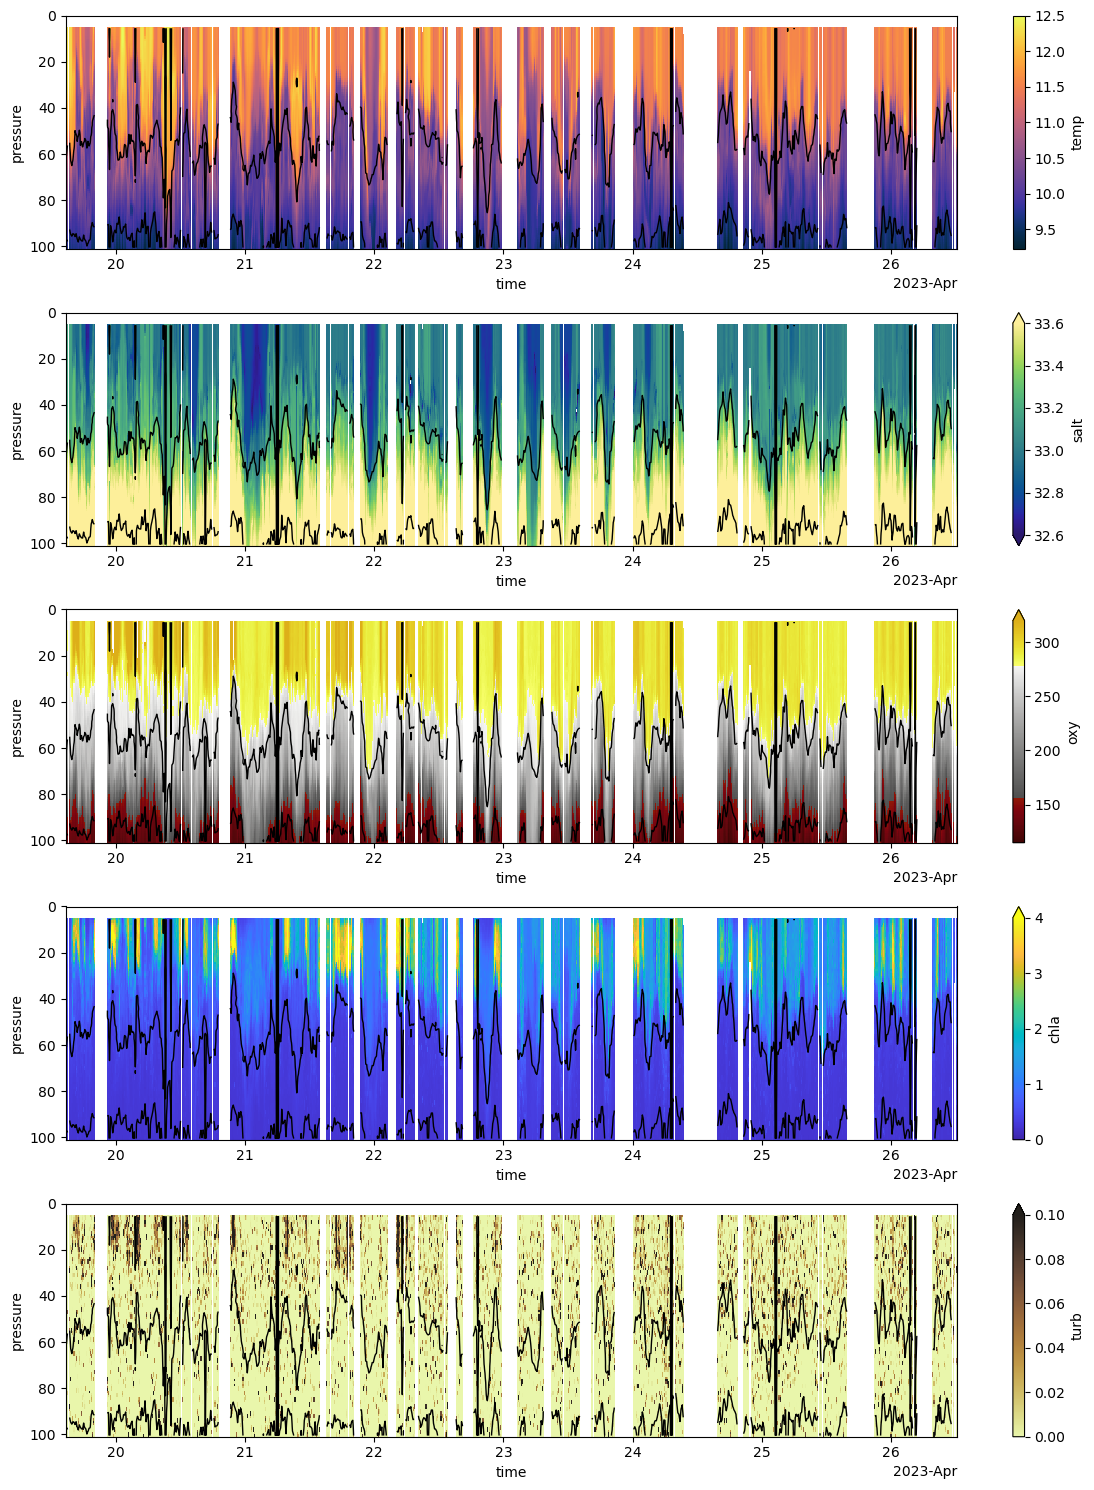

In [21]:
# Transect across feature

t1,t2='2023-04-18','2023-04-26T12'
#t1,t2='2023-04-20T00','2023-04-20T11'
#t1,t2='2023-04-22T18','2023-04-23T00'
#t1,t2='2023-04-22T22:20','2023-04-23T00:10' # actual eddy only
#t1,t2 = '2023-04-22T21:20', '2023-04-22T23'

fig, ax = plt.subplots(5,1,figsize=(12,3*5))
#fig, ax = plt.subplots(5,1,figsize=(6,4*5))
da_ = da.sel(time=slice(t1,t2)).resample(time='0.2H').mean()

da_.temp.plot(ax=ax[0],cmap=cm.thermal,x='time')
da_.salt.plot(ax=ax[1],cmap=cm.haline,x='time',vmin=32.6,vmax=33.6)
da_.oxy.plot(ax=ax[2], cmap=cm.oxy,x='time',vmax=320)
da_.chla.plot(ax=ax[3],cmap=parula,x='time',vmin=0,vmax=4)
da_.turb.plot(ax=ax[4],cmap=cm.turbid,x='time',vmax=0.1)

# add density lines
for axis in ax:
    #axis.set_xticks(da_.time[::2], labels=np.round(da_.lat.values, 2)[::2], rotation=45);
    axis.contour(da_.time,da_.pressure,da_.rho.T,10,colors='k',linewidths=1)
    axis.invert_yaxis()

plt.tight_layout()

#plt.savefig(f'/Users/elise/ocean/drifters_chl/figures/MVP-{t1}-{t2}.png',dpi=800)

plt.show();

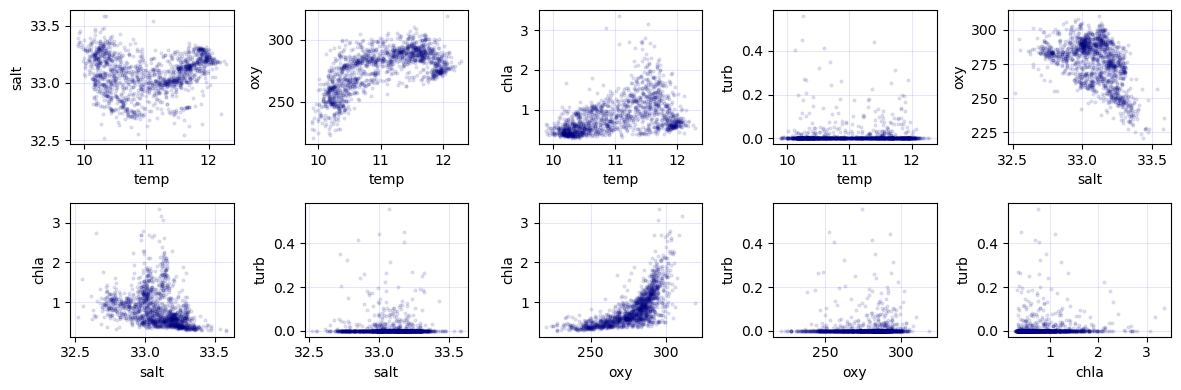

In [160]:
# variables correlations
from itertools import combinations

da_ = da.sel(time=slice(t1,t2)).sel(pressure=40,method='nearest')

variables = ['temp','salt','oxy','chla','turb']
combs = list(combinations(range(len(variables)), 2))

fig, ax = plt.subplots(2,5,figsize=(12,4))
axes = ax.flatten()
for i in range(len(combs)):
    var1=variables[np.array(combs[i])[0]]
    var2=variables[np.array(combs[i])[1]]
    
    axes[i].plot(da_[var1],da_[var2],'o',color='navy',alpha=0.1,markersize=2)
    axes[i].set_xlabel(var1)
    axes[i].set_ylabel(var2)
    axes[i].grid(color='b',alpha=0.1)
    
plt.tight_layout()
plt.show();

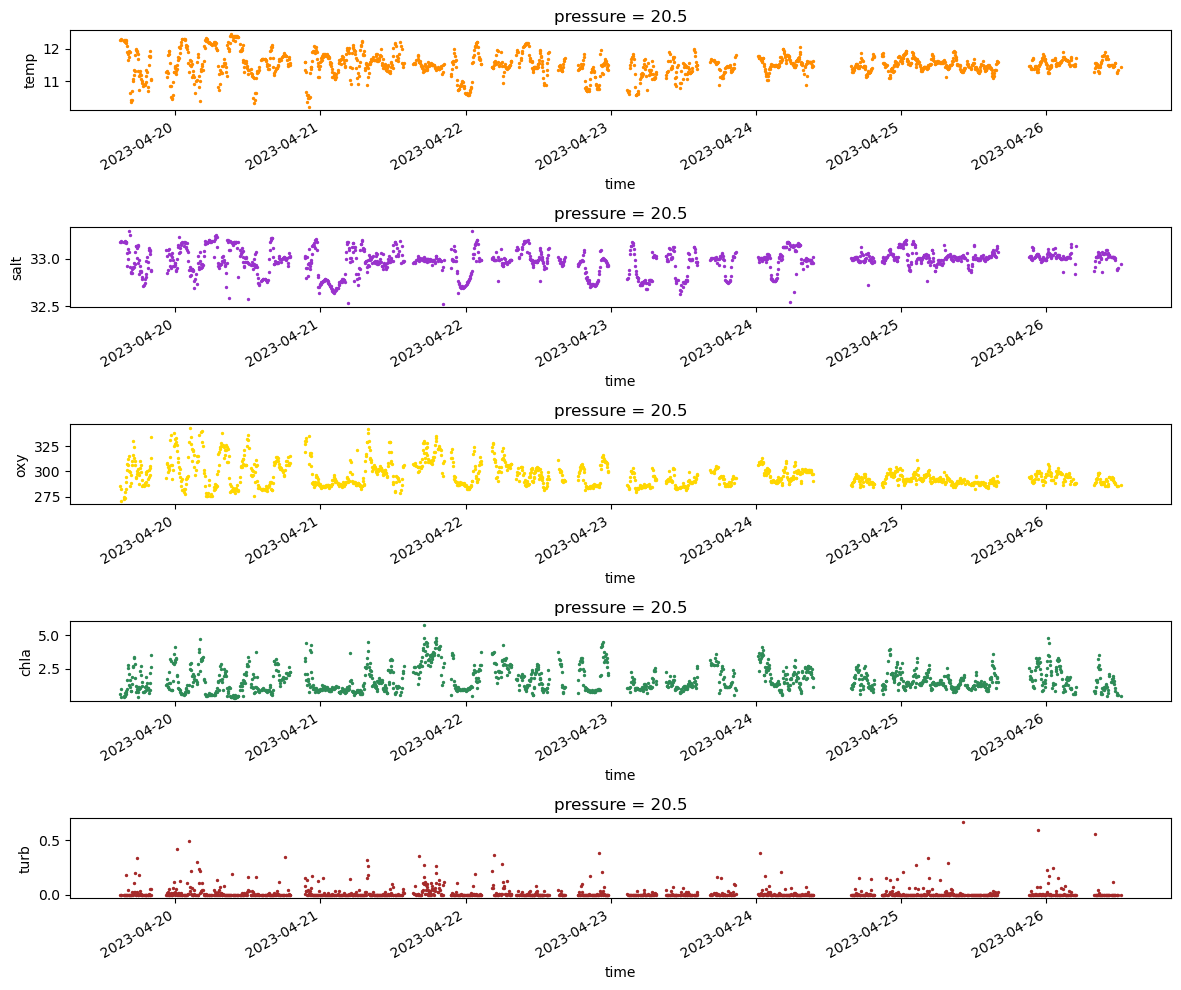

In [179]:
fig, ax = plt.subplots(5,1,figsize=(12,10))
da_ = da.sel(time=slice(t1,t2)).sel(pressure=20,method='nearest')
variables = ['temp','salt','oxy','chla','turb']
colors=['darkorange','darkorchid','gold','seagreen','brown']
for i,var in enumerate(variables):
    da_[var].plot.scatter(x='time',s=2,ax=ax[i],color=colors[i])
plt.tight_layout()
plt.show();

### Water source of the submesoscale eddy


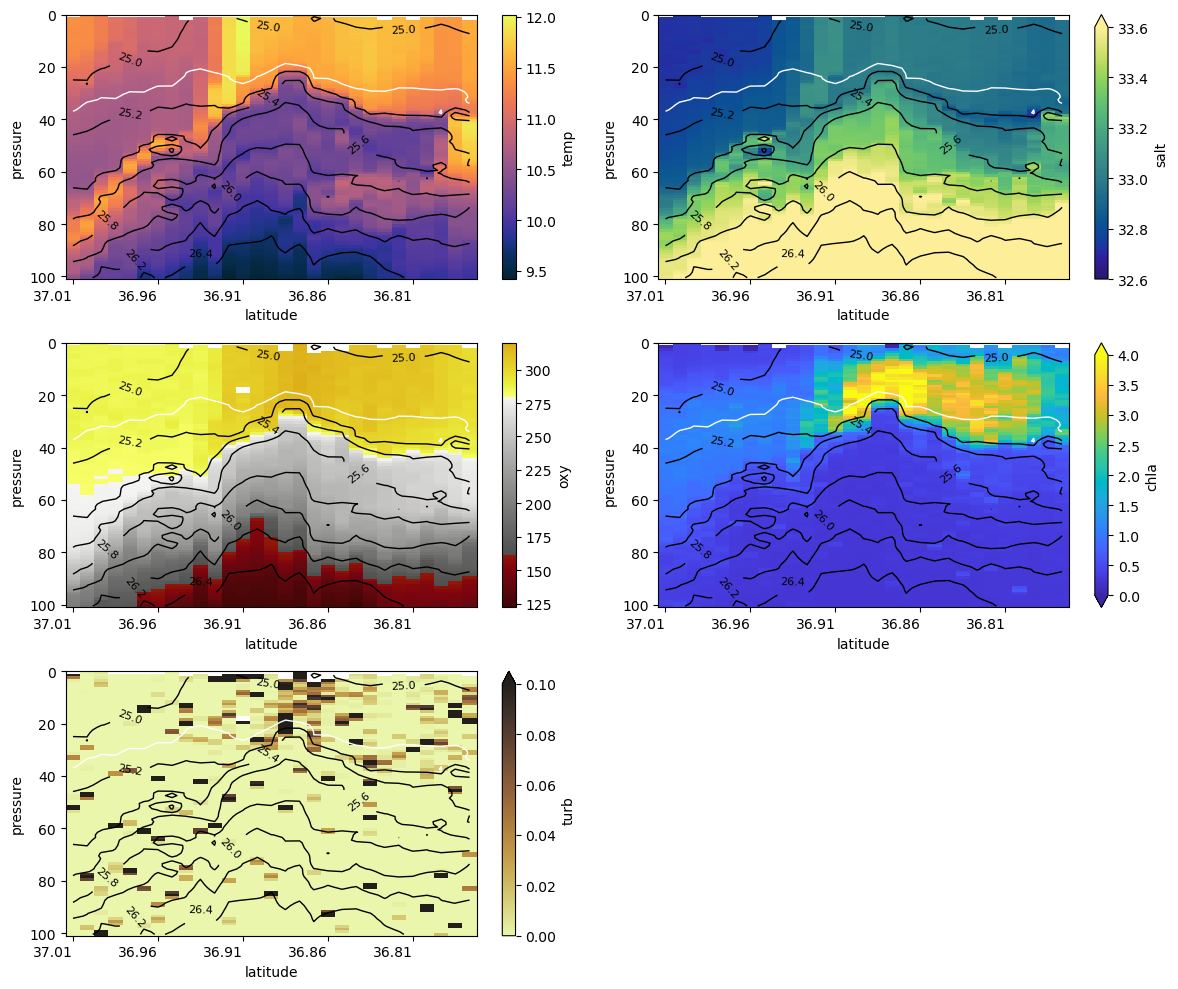

In [284]:

t1,t2 = '2023-04-22T21:20', '2023-04-22T23' # actual eddy only

fig, ax = plt.subplots(3,2,figsize=(12,10))
da_ = da.sel(time=slice(t1,t2)).resample(time='0.08H').mean()

axes = ax.flatten()
x_axis, y_axis, N = da_.lat, da_.pressure, 50
da_.temp.plot(ax=axes[0],cmap=cm.thermal,x='time')
da_.salt.plot(ax=axes[1],cmap=cm.haline,x='time',vmin=32.6,vmax=33.6)
da_.oxy.plot(ax=axes[2], cmap=cm.oxy,x='time',vmax=320)
da_.chla.plot(ax=axes[3],cmap=parula,x='time',vmin=0,vmax=4)
da_.turb.plot(ax=axes[4],cmap=cm.turbid,x='time',vmax=0.1)

# add density lines
for axis in axes:
    axis.set_xticks(da_.time[::6], labels=np.round(da_.lat.values, 2)[::6], rotation=0); axis.set_xlabel('latitude')
    p_rho=axis.contour(da_.time,da_.pressure,da_.rho.T-1000,10,colors='k',linewidths=1)
    axis.clabel(p_rho, inline=True, fontsize=8)
    axis.contour(da_.time,da_.pressure,da_.rho.T-1000,levels=[mean_iso],colors='w',linewidths=1)
    axis.invert_yaxis()

fig.delaxes(axes[-1])
plt.tight_layout()

#plt.savefig(f'/Users/elise/ocean/drifters_chl/figures/submesoscale-eddy/ship-transect-{t1}-{t2}.png',dpi=800)

plt.show();

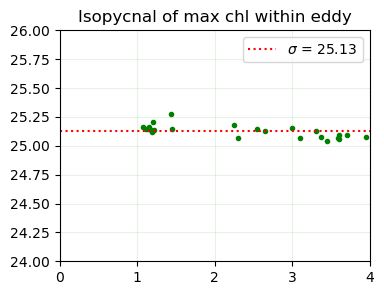

In [228]:
# Find isopycnal of max chl
T = da_.chla.shape[0]
eddy_max_chla = np.empty([T,2])

for i in range(T): # each profile
    profile = da_.isel(time=i)
    idx=np.where(profile.chla == profile.chla.max())[0]

    eddy_max_chla[i,0] = profile.rho[idx].values-1000
    eddy_max_chla[i,1] = profile.chla[idx].values


plt.figure(figsize=(4,3))
plt.plot(eddy_max_chla[:,1],eddy_max_chla[:,0],'.g')

mean_iso =np.mean(eddy_max_chla[:,0])
plt.axhline(y = mean_iso, color = 'r', linestyle = ':', label=f'$\sigma$ = {mean_iso:.2f}') 

plt.xlim(0,4)
plt.ylim(24,26)
plt.legend()
plt.grid(color='g',alpha=0.1)
plt.title('Isopycnal of max chl within eddy');

In [ ]:
# TS diagram
uw = xr.open_dataset(path+'TSG/'+'IOP2_underway.nc')

t1,t2='2023-04-22T22:30','2023-04-23T00:10'
data = uw.sel(time=slice(t1,t2))


# density lines
salt_mesh, temp_mesh = np.meshgrid(
    np.linspace(uw.salt.min(),uw.salt.max(),40),
    np.linspace(uw.temp.min(),uw.temp.max(),40)
)
rho_mesh = gsw.density.sigma0(salt_mesh,temp_mesh)

uw_selected = uw.where((uw.temp > data.temp.min()) & (uw.temp < data.temp.max()) 
                       & (uw.salt > data.salt.min()) & (uw.salt < data.salt.max()), drop=True)

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(12,4))

# TS diagram
ax=axes[0]

# density lines
contour = ax.contour(salt_mesh,temp_mesh,rho_mesh,colors='k',linewidths=0.5)
ax.clabel(contour, inline=True, fontsize=8)

# all shipboard data
p=ax.scatter(uw.salt[::100],uw.temp[::100], s=40, facecolors='none', 
            edgecolors='lightsteelblue',alpha=0.1, label='ship')
#plt.colorbar(p,ax=ax)

# submesoscale cyclonic eddy
ax.scatter(data.salt.values[::20],data.temp.values[::20], c='green',
            cmap='RdYlGn', marker='o', edgecolor='None', linestyle='-', linewidth=1 ,
            vmin=-1e-4,vmax=1e-4, alpha=0.3, zorder=101, label='eddy')

ax.set_title('TS Diagram')
ax.set_xlabel('Salinity (psu)'); ax.set_ylabel('Temperature (C)')
ax.legend(markerscale=1.5)
#plt.xlim([32.50,33.25]); plt.ylim([11,13])

# Location of Eddy water
ax=axes[1]
ax.plot(uw.lon, uw.lat, 'k-', linewidth=0.4, alpha=0.3)
ax.scatter(uw_selected.lon[::10], uw_selected.lat[::10], edgecolor='lightsteelblue', 
            facecolor='None', alpha=0.1, zorder=101)
ax.scatter(data.lon[::10], data.lat[::10], edgecolor='green', 
            facecolor='None', alpha=0.3, zorder=101)
coastline(ax)
smode_pgon(ax)
ax.set_xlim(-126,-122); ax.set_ylim(36,38)


plt.show();

In [2]:
thetao = xr.open_dataset('/Users/elise/ocean/freshwater/data/cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m_1692143664470.nc').thetao
so     = xr.open_dataset('/Users/elise/ocean/freshwater/data/cmems_mod_glo_phy-so_anfc_0.083deg_P1D-m_1692143118754.nc').so


# TS diagram of CMEMS
contour = plt.contour(salt_mesh,temp_mesh,rho_mesh,colors='k',linewidths=0.5)
plt.clabel(contour, inline=True, fontsize=8)

thetao=thetao.sel(time='2023-04',latitude=slice(36,38),longitude=slice(-124.5,-122)).isel(depth=0)
so=so.sel(time='2023-04',latitude=slice(36,38),longitude=slice(-124.5,-122)).isel(depth=0)

plt.scatter(so[::2,::2],thetao[::2,::2], s=40, facecolors='none', 
            edgecolors='lightsteelblue',alpha=0.1, label='cmems')


plt.xlim([32.25,33.75]); plt.ylim([10,15])



NameError: name 'xr' is not defined

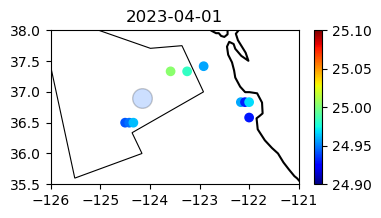

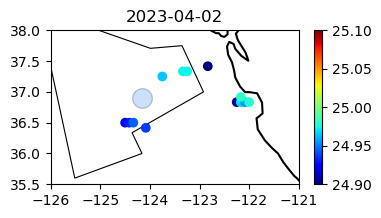

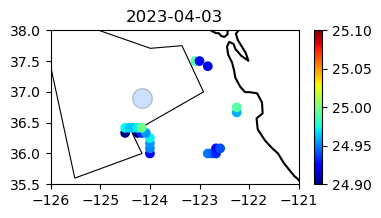

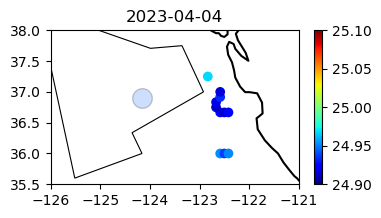

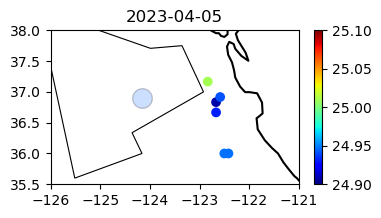

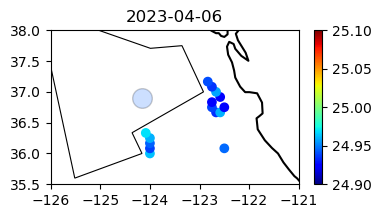

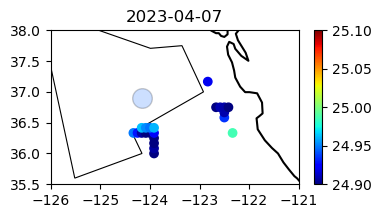

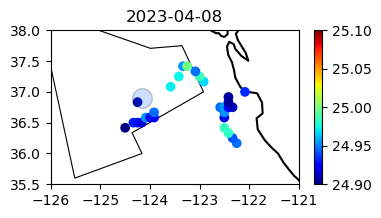

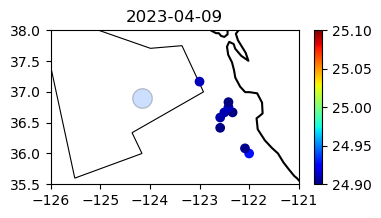

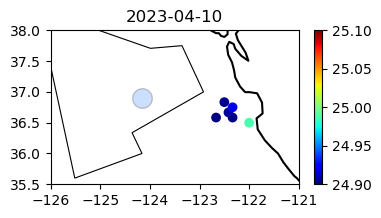

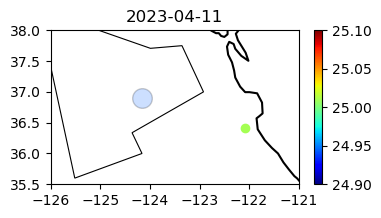

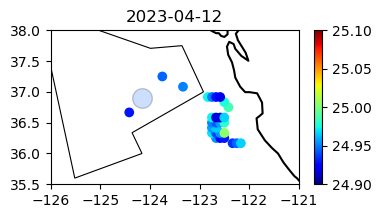

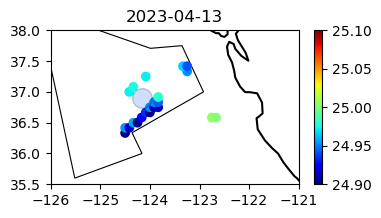

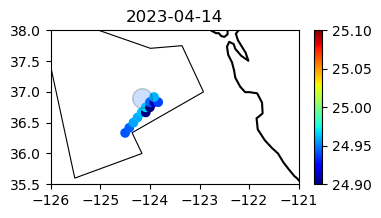

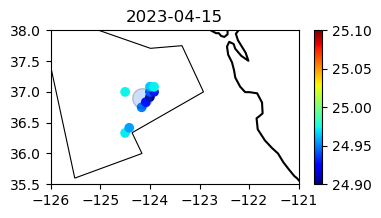

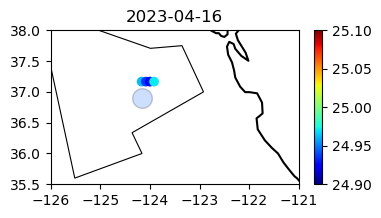

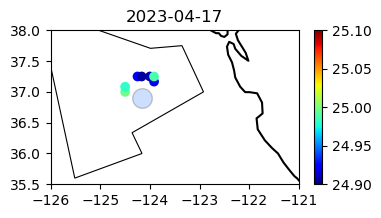

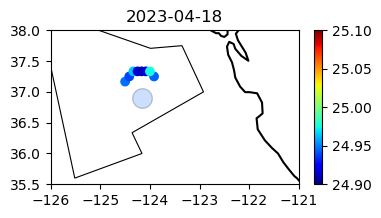

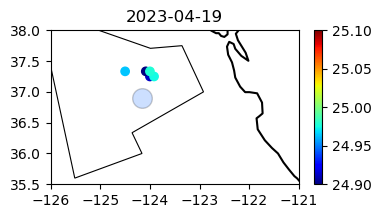

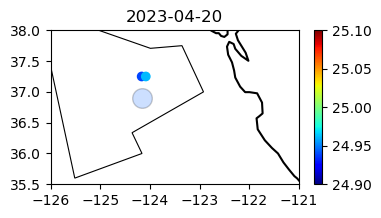

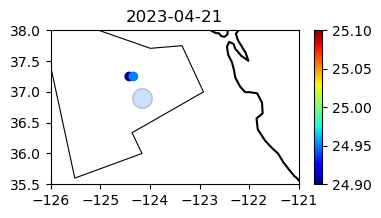

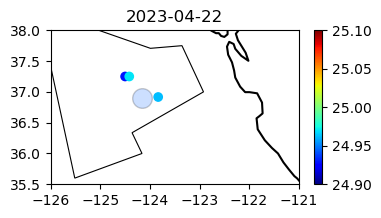

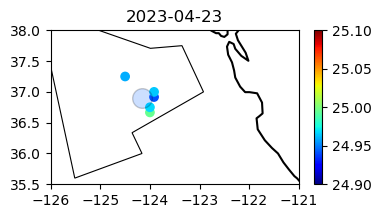

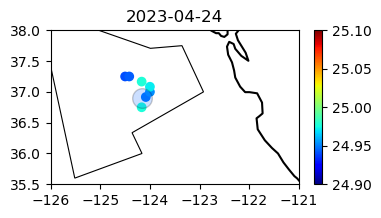

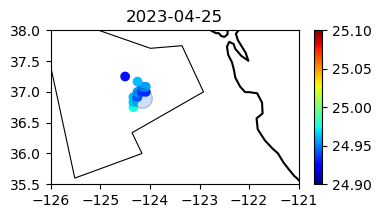

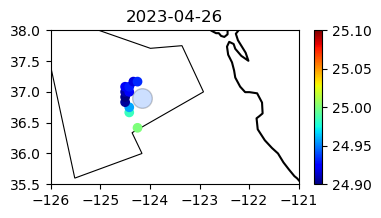

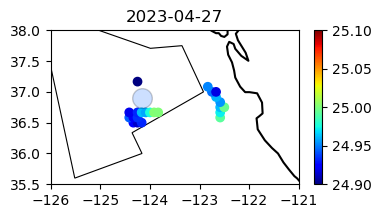

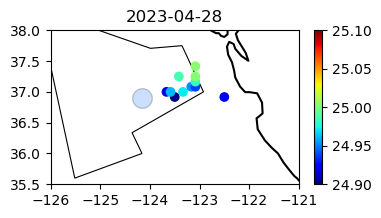

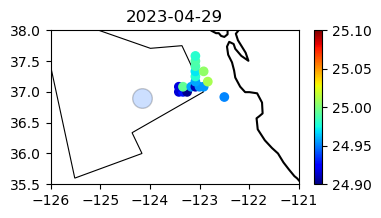

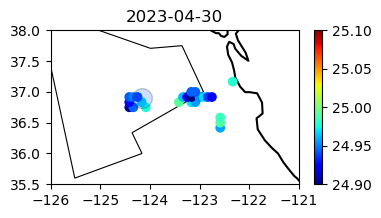

In [743]:
ds0 = xr.Dataset(
    {
        'thetao': (('time','lat', 'lon'), thetao.values),
        'so': (('time','lat', 'lon'), so.values)
    },
    coords={
        'time': thetao.time,
        'lat': thetao.latitude.values,
        'lon': so.longitude.values
    }
)
for i in range(30):
    ds = ds0.isel(time=i)
    condition = ((ds.thetao > data.temp.min()) & (ds.thetao < data.temp.max())
                 & (ds.so > data.salt.min()) & (ds.so < data.salt.max()))
    
    # Location of Eddy water
    fig,ax=plt.subplots(1,1,figsize=(4,2))
    #ax.plot(uw.lon, uw.lat, 'k-', linewidth=0.4, alpha=0.3)
    
    xx, yy = np.meshgrid(ds.where(condition,drop=True).lon, ds.where(condition,drop=True).lat)
    rho = gsw.density.sigma0(ds.where(condition, drop=True).so,ds.where(condition, drop=True).thetao)
    p=ax.scatter(xx,yy, c = np.squeeze(rho.values),
                facecolor='None', zorder=101, vmin=24.9,vmax=25.1, cmap='jet')
    ax.scatter(data.lon[0], data.lat[0], c=gsw.density.sigma0(data.salt[0],data.temp[0]), s=200,
                facecolor='None', alpha=0.2, zorder=101, edgecolor='k',vmin=24.9,vmax=25.1, cmap='jet')
    coastline(ax)
    smode_pgon(ax)
    plt.colorbar(p,ax=ax)
    ax.set_xlim(-126,-121); ax.set_ylim(35.5,38)
    ax.set_title(str(ds.time.values)[0:10])
    plt.show();